In [ ]:
try:
    import firedrake
except ImportError:
    !wget "https://fem-on-colab.github.io/releases/firedrake-install-release-real.sh" -O "/tmp/firedrake-install.sh" && bash "/tmp/firedrake-install.sh"
    import firedrake

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [1]:
from firedrake import *
import matplotlib.pyplot as plt
import numpy as np

from firedrake.petsc import PETSc

firedrake:WARNING OMP_NUM_THREADS is not set or is set to a value greater than 1, we suggest setting OMP_NUM_THREADS=1 to improve performance


In [2]:
# Get current path: all relative paths that you may use for input/output start from here.
#
# - Colab:  The default path is /content, and your GDrive folder is accessible (if mounted) at /content/drive/MyDrive
#
# - local:  If running on your local machine, current_path is the position WHERE YOU LAUNCHED THE NOTEBOOK KERNEL BY 'jupyter notebook'
#           and NOT the directory in which this ipynb file is saved.
#           If you want to modify your current path, go to the terminal, stop the kernel (ctrl-C + press y), then move to the desired path by
#           cd my/desired/path/starting/from/here
#           and then launch 'jupyter notebook'.
import os
current_path = os.getcwd()
print(current_path)

my_io_path =  current_path + "/cfd-labs/Lab12-Level-Set-Method/"
# my_io_path = current_path+"/"
print(my_io_path)

/home/aless
/home/aless/cfd-labs/Lab12-Level-Set-Method/


---
---
# Exercise 1
## Multi-phase flow by level-set method.

firedrake:WARNING Subdomain (1,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (2,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (3,) is empty. This is likely an error. Did you choose the right label?
firedrake:WARNING Subdomain (4,) is empty. This is likely an error. Did you choose the right label?


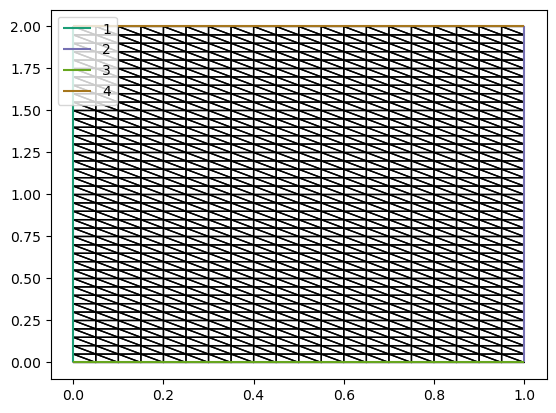

In [3]:
n = 20  # per unit length
mesh = RectangleMesh(n, 2*n, 1.0, 2.0)
fig, ax = plt.subplots()
triplot(mesh, axes=ax)
ax.legend(loc='upper left')

In [4]:
# Function spaces
V = VectorFunctionSpace(mesh, 'P', 2)   # velocity
Q = FunctionSpace(mesh, 'P', 1)         # pressure
W = MixedFunctionSpace([V, Q])
Z = FunctionSpace(mesh, 'P', 1)         # level-set

# Data and boundary conditions
mu = Constant(0.1)
g = Constant((0.0,-1.0))
rho1 = 10.0
rho2 = 1.e-4
smoother_rho = False
T = 4.0
dt = 1.e-2

bcNS_lateral = DirichletBC(W.sub(0).sub(0), Constant(0.0), (1, 2))
bcNS_top_bot = DirichletBC(W.sub(0), Constant((0.,0.)), (3,4))
bcsNS = (bcNS_lateral, bcNS_top_bot)

nullsp = MixedVectorSpaceBasis(
        W, [W.sub(0), VectorSpaceBasis(constant=True)]
    )

firedrake:WARNING No comm specified for VectorSpaceBasis, COMM_WORLD assumed


### Variational problems

In [5]:
def time_step_NS(u, v, p, q, rhoh, mu, g, dt, u_old):
    # u,p   :   TrialFunctions
    # v,q   :   TestFunctions
    # rhoh      density Function
    # u_old :   old velocity Function

    a = rhoh / dt * inner(u, v) * dx \
        + 2 * mu * inner(sym(grad(u)), sym(grad(v))) * dx  \
        + rhoh * inner(dot(grad(u), u_old), v) * dx  \
        - div(v) * p * dx  \
        + q * div(u) * dx
    L = rhoh / dt * inner(u_old, v) * dx \
        + rhoh * inner(g, v) * dx

    return a, L

def time_step_level_set(phi, psi, uh, dt, phi_old):
    # phi       :   TrialFunction
    # psi       :   TestFunction
    # phi_old   :   old level-set Function
    # uh        :   advecting velocity Function


    a = 1.0 / dt * phi * psi * dx  \
        + inner(grad(phi), uh) * psi * dx
    L = 1.0 / dt * phi_old * psi * dx

    return a, L

### Initialization and post-processing setup.

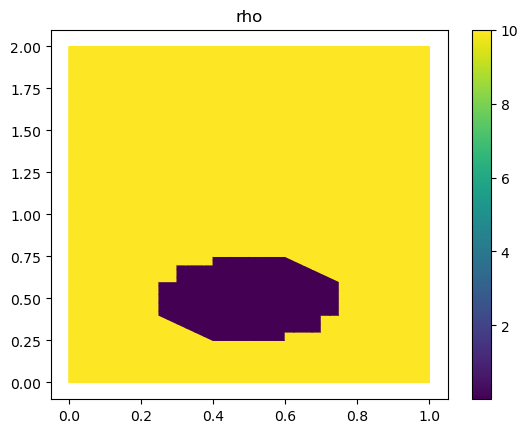

In [10]:
# Initialization
wh = Function(W)
uh, ph = wh.subfunctions

R = 0.25
phih = Function(Z)
x = SpatialCoordinate(mesh)
# phih.interpolate( 1.0/(2*R) * ( (x[0]-0.5)**2 + (x[1]-0.5)**2 - R**2 ) )
phih.interpolate( sqrt( (x[0]-0.5)**2 + (x[1]-0.5)**2 ) - R )

rhoh = Function(Z)
rhoh = Function(FunctionSpace(mesh, 'DG', 0))
if smoother_rho:
    h = CellDiameter(mesh)
    heaviside = Function(Z)
    heaviside.interpolate(0.5*(1+phih/sqrt(phih**2+(h)**2)))    # fixed
    rhoh.interpolate(rho1*heaviside + rho2*(1-heaviside))       # gradient distributed over 1 element
else:
    rhoh.interpolate(conditional(gt(phih, 0.0), rho1, rho2))    # piece-wise constant Function

# Plot of initial density
fig, ax = plt.subplots()
col = tripcolor(rhoh, axes=ax)
plt.colorbar(col)
plt.title('rho')

# vtk output for Paraview
basename = 'lab12_'
from firedrake import VTKFile
outfileU = VTKFile(my_io_path+"output/"+basename+"velocity.pvd")
outfileP = VTKFile(my_io_path+"output/"+basename+"pressure.pvd")
outfilePhi = VTKFile(my_io_path+"output/"+basename+"phi.pvd")
uh.rename("Velocity")   # this name will be used in Paraview
ph.rename("Pressure")   # this name will be used in Paraview
phih.rename("Phi")   # this name will be used in Paraview
outfileU.write(uh)
outfileP.write(ph)
outfilePhi.write(phih)

### FE functions: trial, test, old solution

In [11]:
u, p = TrialFunctions(W)
v, q = TestFunctions(W)
u_old = Function(V)
u_old.assign(uh)

phi = TrialFunction(Z)
psi = TestFunction(Z)
phi_old = Function(Z)
phi_old.assign(phih)

Coefficient(WithGeometry(FunctionSpace(<firedrake.mesh.MeshTopology object at 0x7b564b52c1a0>, FiniteElement('Lagrange', triangle, 1), name=None), Mesh(VectorElement(FiniteElement('Lagrange', triangle, 1), dim=2), 1)), 244)

### Time loop

In [12]:
t_vec = np.arange(0, T+0.1*dt, dt)  # T+0.1*dt to include also T: range/arange exclude the upper bound of the range
mass = [0.0] * (len(t_vec))
mass[0] = assemble(rhoh * dx)

for ii in range(1, len(t_vec)):     # start from 1 to skip t=0
    t = t_vec[ii]

    # re-define NS problem to update rhoh terms
    a_NS, L_NS = time_step_NS(u, v, p, q, rhoh, mu, g, dt, u_old)
    pb_NS = LinearVariationalProblem(a_NS, L_NS, wh, bcsNS)
    solver_NS = LinearVariationalSolver(pb_NS, nullspace=nullsp)#, solver_parameters=param)
    solver_NS.solve()
    uh, ph = wh.subfunctions

    a_phi, L_phi = time_step_level_set(phi, psi, uh, dt, phi_old)
    pb_phi = LinearVariationalProblem(a_phi, L_phi, phih)
    solver_phi =  LinearVariationalSolver(pb_phi)#, solver_parameters=param)
    solver_phi.solve()

    if (ii % 10 == 0):
        uh.rename("Velocity")
        ph.rename("Pressure")
        phih.rename("Phi")
        outfileU.write(uh, time=t)
        outfileP.write(ph, time=t)
        outfilePhi.write(phih, time=t)

    # Update solutions and parameters for next time step
    u_old.assign(uh)
    phi_old.assign(phih)
    if smoother_rho:
        h = CellDiameter(mesh)
        heaviside = Function(Z)
        heaviside.interpolate(0.5*(1+phih/sqrt(phih**2+(h)**2)))    # fixed
        rhoh.interpolate(rho1*heaviside + rho2*(1-heaviside))       # gradient distributed over 1 element
    else:
        rhoh.interpolate(conditional(gt(phih, 0.0), rho1, rho2))    # piece-wise constant Function

    mass[ii] = assemble(rhoh * dx)

    print(f"Time = {t:.2f}, mass = {mass[ii]:.6f}")



Time = 0.01, mass = 17.975020
Time = 0.02, mass = 17.975020
Time = 0.03, mass = 17.975020
Time = 0.04, mass = 17.987520
Time = 0.05, mass = 17.987520
Time = 0.06, mass = 17.987520
Time = 0.07, mass = 17.987520
Time = 0.08, mass = 18.025020
Time = 0.09, mass = 18.037520
Time = 0.10, mass = 18.037520
Time = 0.11, mass = 18.037520
Time = 0.12, mass = 18.037520
Time = 0.13, mass = 18.050019
Time = 0.14, mass = 18.062519
Time = 0.15, mass = 18.062519
Time = 0.16, mass = 18.050019
Time = 0.17, mass = 18.050019
Time = 0.18, mass = 18.050019
Time = 0.19, mass = 18.050019
Time = 0.20, mass = 18.050019
Time = 0.21, mass = 18.050019
Time = 0.22, mass = 18.062519
Time = 0.23, mass = 18.050019
Time = 0.24, mass = 18.050019
Time = 0.25, mass = 18.062519
Time = 0.26, mass = 18.050020
Time = 0.27, mass = 18.037520
Time = 0.28, mass = 18.050019
Time = 0.29, mass = 18.050020
Time = 0.30, mass = 18.050020
Time = 0.31, mass = 18.062519
Time = 0.32, mass = 18.075019
Time = 0.33, mass = 18.075019
Time = 0.3

KeyboardInterrupt: 

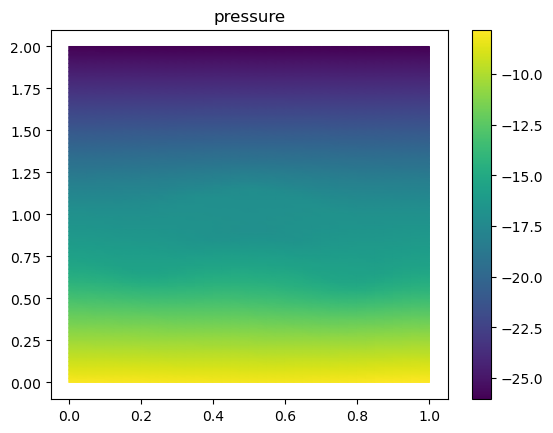

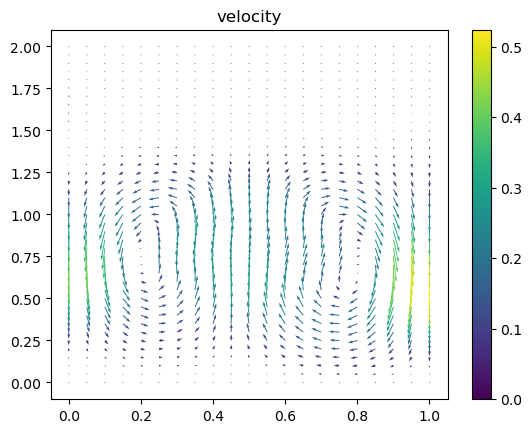

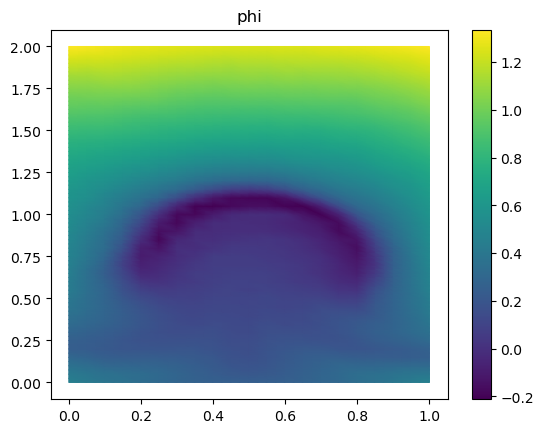

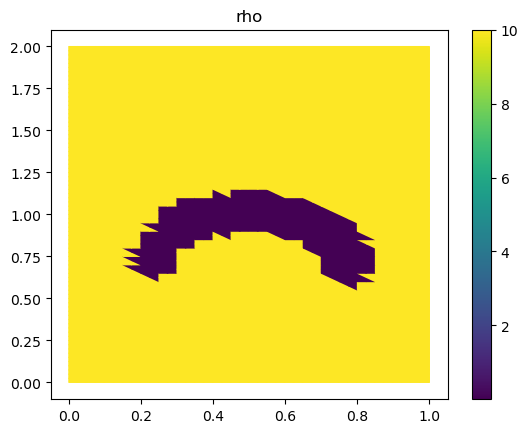

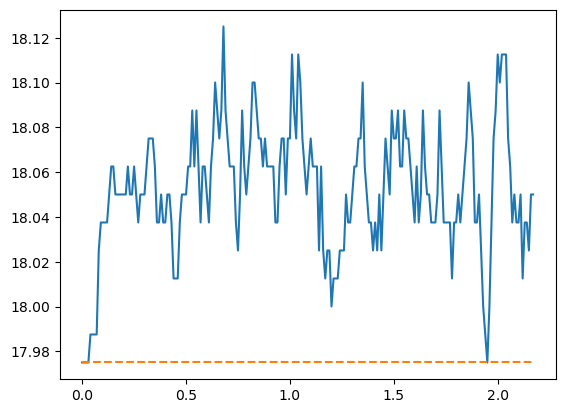

In [13]:
fig, ax = plt.subplots()
col = tripcolor(ph, axes=ax)
plt.colorbar(col)
plt.title('pressure')
fig, ax = plt.subplots()
col = quiver(uh, axes=ax)
plt.colorbar(col)
plt.title('velocity')

fig, ax = plt.subplots()
col = tripcolor(phih, axes=ax)
plt.colorbar(col)
plt.title('phi')
fig, ax = plt.subplots()
col = tripcolor(rhoh, axes=ax)
plt.colorbar(col)
plt.title('rho')

fig, ax1 = plt.subplots()
line1 = ax1.plot(t_vec,
                 [float('nan') if x==0 else x for x in mass],
                    # replace 0 with nan to prevent plotting of 0 values
                    # -> useful if execution is interrupted before filling the whole mass vector
                 label='mass')
line2 = ax1.plot(t_vec,
                 [float('nan') if x==0 else mass[0] for x in mass],
                    # replace 0 with nan to prevent plotting of 0 values
                    # -> useful if execution is interrupted before filling the whole mass vector
                 '--',
                 label='initial value')